<a href="https://colab.research.google.com/github/Anaaaslagi/Tugas1A_AnasGhifari_5026221155/blob/main/Week2_APPSREV_TJ_Transjakarta_Preprocessing_(Anas).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Instalasi Library

In [67]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn
!pip install pandas nltk requests Sastrawi -q

## Upload Dataset File

In [68]:
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

try:
    df_tj = pd.read_csv('df_tj_raw.csv')
    print("File berhasil dimuat.")
except FileNotFoundError:
    print("Error: File tidak ditemukan. Pastikan file berada di direktori yang sama.")

File berhasil dimuat.


In [69]:
df_tj

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,bde4ccb0-d440-461c-8a10-ee2d6ee0e815,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍,5,0,2.9.0,2025-10-05 15:49:49,NaN,NaN,2.9.0
1,05b3aa4e-2214-4c5c-b193-d3d824f88c8d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi lemot gk guna.gk mau respon pas login...,1,0,2.9.0,2025-10-04 19:49:12,NaN,NaN,2.9.0
2,19bd7606-fa19-4908-91f4-51b8426b3434,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baru coba,5,0,NaN,2025-10-04 14:06:36,NaN,NaN,NaN
3,dcbb0018-4af8-449d-80bf-c89767ec1152,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi nya mempermudah banget, tetapi kalo o...",4,0,2.9.0,2025-10-04 13:33:11,NaN,NaN,2.9.0
4,a63a99d1-bc93-42b1-bd1a-d20a8170e576,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat baik,5,0,NaN,2025-10-04 09:54:37,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3011,cdd9f5f2-b4cb-44c2-814e-860e0688f3d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantaps,5,5,1.4,2024-05-16 18:10:02,NaN,NaN,1.4
3012,66859930-33cc-484a-9c0a-f25534958578,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 11:52:59,NaN,NaN,1.8
3013,eb386bcd-d074-448e-b636-8f8b4d20ecb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 16:42:40,NaN,NaN,1.4
3014,43b40878-dcff-44b8-bed5-2dfb89bc0880,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-11 20:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 13:29:46,1.4


In [70]:
df_tj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3016 entries, 0 to 3015
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              3016 non-null   object
 1   userName              3016 non-null   object
 2   userImage             3016 non-null   object
 3   content               3016 non-null   object
 4   score                 3016 non-null   int64 
 5   thumbsUpCount         3016 non-null   int64 
 6   reviewCreatedVersion  2534 non-null   object
 7   at                    3016 non-null   object
 8   replyContent          4 non-null      object
 9   repliedAt             4 non-null      object
 10  appVersion            2534 non-null   object
dtypes: int64(2), object(9)
memory usage: 259.3+ KB


In [71]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download Indonesian stopwords if not available
nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_tj[text_column].dropna().astype(str))



[nltk_data] Downloading package stopwords to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [72]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_tj.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,👍,5,0,2.9.0,2025-10-05 15:49:49,NaN,NaN
1,aplikasi lemot gk guna.gk mau respon pas login...,1,0,2.9.0,2025-10-04 19:49:12,NaN,NaN
2,baru coba,5,0,NaN,2025-10-04 14:06:36,NaN,NaN
3,"aplikasi nya mempermudah banget, tetapi kalo o...",4,0,2.9.0,2025-10-04 13:33:11,NaN,NaN
4,sangat baik,5,0,NaN,2025-10-04 09:54:37,NaN,NaN
...,...,...,...,...,...,...,...
3011,Mantaps,5,5,1.4,2024-05-16 18:10:02,NaN,NaN
3012,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 11:52:59,NaN,NaN
3013,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 16:42:40,NaN,NaN
3014,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-11 20:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 13:29:46


## Tokenization

In [73]:
import nltk
from nltk.tokenize import word_tokenize

# Download punkt if not already present
nltk.download('punkt')
nltk.download('punkt_tab') # Download the punkt_tab resource

def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

# Apply tokenization to the 'content' column
df_tj['tokenized_content'] = df_tj['content'].astype(str).apply(tokenize_text)

# Display the DataFrame with the new 'tokenized_content' column
df_tj[['content', 'tokenized_content']]

[nltk_data] Downloading package punkt to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,content,tokenized_content
0,👍,[👍]
1,aplikasi lemot gk guna.gk mau respon pas login...,"[aplikasi, lemot, gk, guna.gk, mau, respon, pa..."
2,baru coba,"[baru, coba]"
3,"aplikasi nya mempermudah banget, tetapi kalo o...","[aplikasi, nya, mempermudah, banget, ,, tetapi..."
4,sangat baik,"[sangat, baik]"
...,...,...
3011,Mantaps,[Mantaps]
3012,Sudah enggak crash kalau pilih profil,"[Sudah, enggak, crash, kalau, pilih, profil]"
3013,"Aplikasi kocag, gk becus bikin aplikasi, masuk...","[Aplikasi, kocag, ,, gk, becus, bikin, aplikas..."
3014,"Aplikasi gak jelas, server eror, loading lama,...","[Aplikasi, gak, jelas, ,, server, eror, ,, loa..."


In [74]:
# Example Tokenization

example_token = df_tj['content'].iloc[2744]

print('Example content to tokenize:')
print(example_token)

print('\nTokenized content:')
print(word_tokenize(example_token))

Example content to tokenize:
Mantap, jadi bisa tau posisi bus, semua rute dan halte halte transjakarta

Tokenized content:
['Mantap', ',', 'jadi', 'bisa', 'tau', 'posisi', 'bus', ',', 'semua', 'rute', 'dan', 'halte', 'halte', 'transjakarta']


## Lowering Case

In [75]:
def lower_tokenized(tokens):
    return [token.lower() for token in tokens]

df_tj['lower_tokenized_content'] = df_tj['tokenized_content'].apply(lower_tokenized)
df_tj[['tokenized_content', 'lower_tokenized_content']]

,tokenized_content,lower_tokenized_content
0,[👍],[👍]
1,"[aplikasi, lemot, gk, guna.gk, mau, respon, pa...","[aplikasi, lemot, gk, guna.gk, mau, respon, pa..."
2,"[baru, coba]","[baru, coba]"
3,"[aplikasi, nya, mempermudah, banget, ,, tetapi...","[aplikasi, nya, mempermudah, banget, ,, tetapi..."
4,"[sangat, baik]","[sangat, baik]"
...,...,...
3011,[Mantaps],[mantaps]
3012,"[Sudah, enggak, crash, kalau, pilih, profil]","[sudah, enggak, crash, kalau, pilih, profil]"
3013,"[Aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, gk, becus, bikin, aplikas..."
3014,"[Aplikasi, gak, jelas, ,, server, eror, ,, loa...","[aplikasi, gak, jelas, ,, server, eror, ,, loa..."


In [76]:
# Lowering Case
example_lowering = df_tj['tokenized_content'].iloc[3]

print('Example token to lower:')
print(example_lowering)

lowered_tokens = [token.lower() for token in example_lowering]

print('\nLower Tokenized content:')
print(lowered_tokens)

Example token to lower:
['aplikasi', 'nya', 'mempermudah', 'banget', ',', 'tetapi', 'kalo', 'operasional', 'di', 'jalan', 'tol', 'jangan', 'dibatasi', '20km/jam', 'dong', 'min', ',', 'bisa', 'kali', 'maksimal', 'nya', 'ditambah', 'khusus', 'dijalan', 'tol', 'saja', '.']

Lower Tokenized content:
['aplikasi', 'nya', 'mempermudah', 'banget', ',', 'tetapi', 'kalo', 'operasional', 'di', 'jalan', 'tol', 'jangan', 'dibatasi', '20km/jam', 'dong', 'min', ',', 'bisa', 'kali', 'maksimal', 'nya', 'ditambah', 'khusus', 'dijalan', 'tol', 'saja', '.']


##Stopwords Removal
Indonesian Stopwords

In [77]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [78]:
print(len(indonesian_stopwords))

758


,Word,Frequency
0,aplikasi,1201
1,membantu,708
2,bus,631
3,transjakarta,625
4,nya,554
5,rute,548
6,mudah,435
7,banget,415
8,bagus,337
9,aplikasinya,316


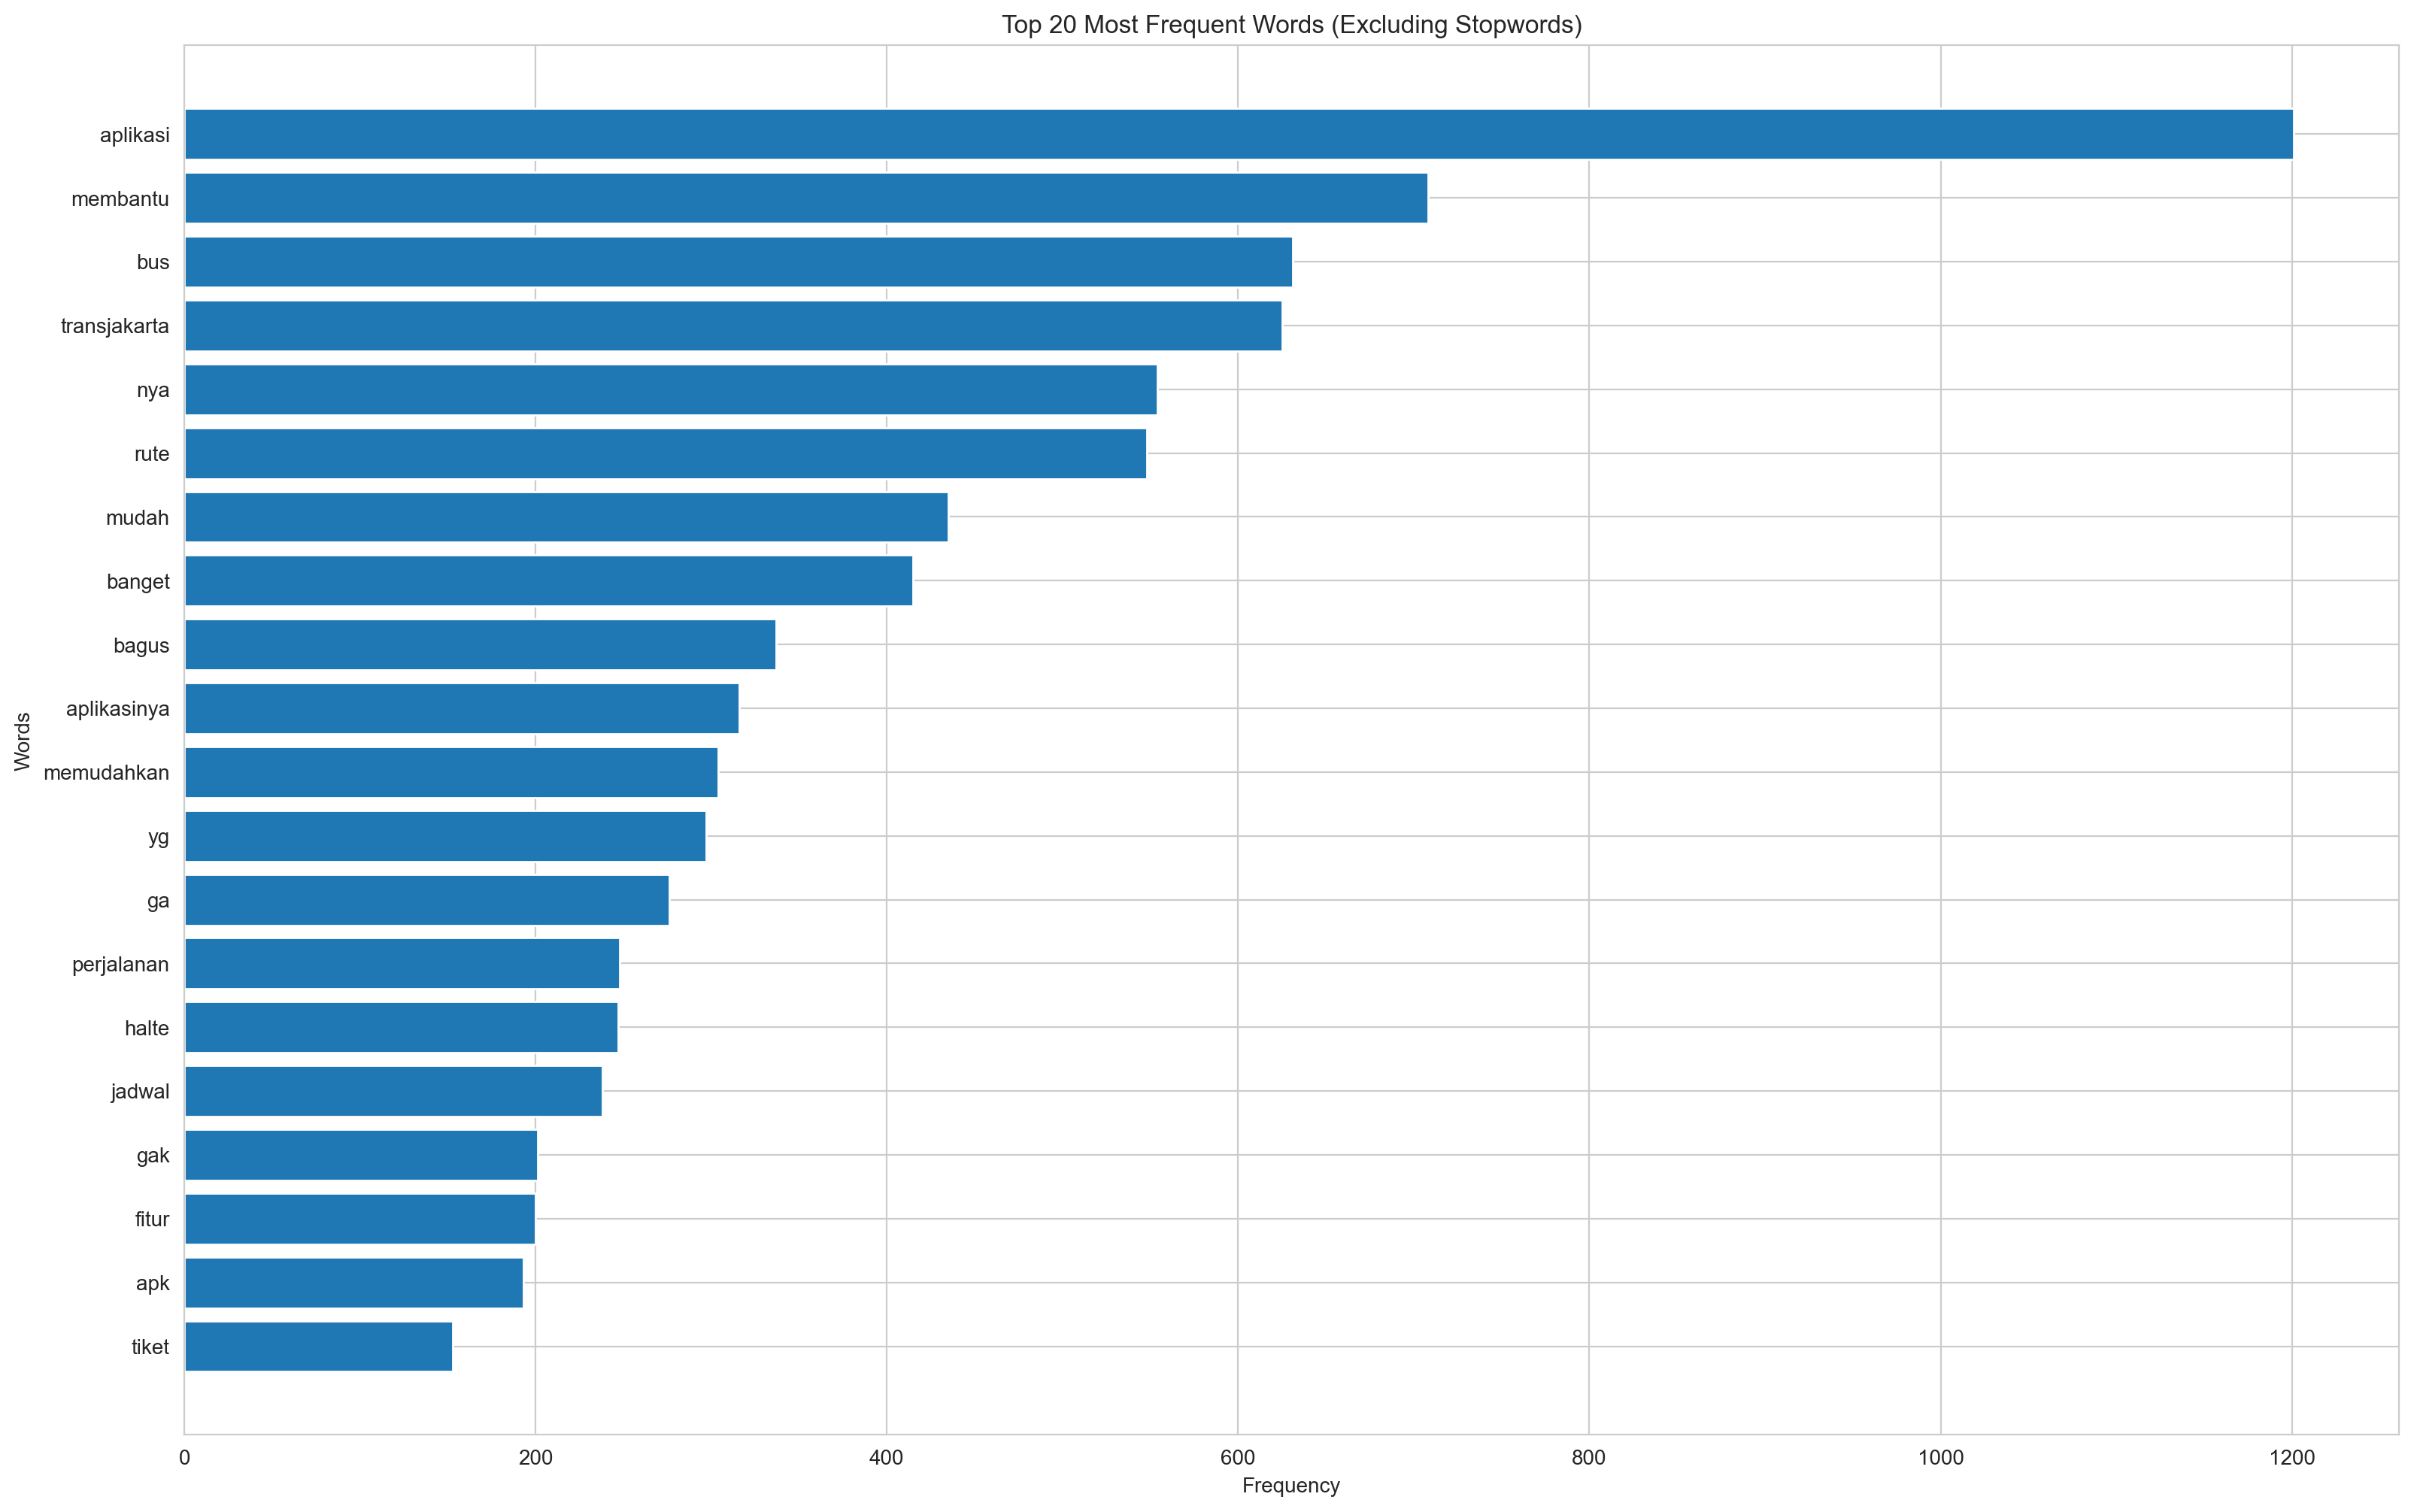

In [79]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_tj[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(20)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [80]:
common_words

[('aplikasi', 1201),
 ('membantu', 708),
 ('bus', 631),
 ('transjakarta', 625),
 ('nya', 554),
 ('rute', 548),
 ('mudah', 435),
 ('banget', 415),
 ('bagus', 337),
 ('aplikasinya', 316),
 ('memudahkan', 304),
 ('yg', 297),
 ('ga', 276),
 ('perjalanan', 248),
 ('halte', 247),
 ('jadwal', 238),
 ('gak', 201),
 ('fitur', 200),
 ('apk', 193),
 ('tiket', 153)]

Custom Stopwords

In [81]:
# Tambah custom stopwords
custom_stopwords = ["good", "nya", "banget", "yg", "ga", "gak", "apk", "update", "gk", "mna", "kmna", "jdi"]

# Pastikan indonesian_stopwords juga merupakan sebuah list atau set
# Asumsi indonesian_stopwords sudah ada dan berbentuk list
# indonesian_stopwords = [...]

# 2. Gabungkan stopwords bawaan dan custom stopwords
# --- PERBAIKAN DI SINI ---
# Ubah list menjadi set agar bisa menggunakan metode .union()
all_stopwords = set(indonesian_stopwords).union(custom_stopwords)

# --- Alternatif lain yang lebih singkat ---
# all_stopwords = set(indonesian_stopwords + custom_stopwords)


def remove_stopwords(tokens):
    return [token for token in tokens if token not in all_stopwords]

df_tj['removed_stopwords_content'] = df_tj['lower_tokenized_content'].apply(remove_stopwords)
df_tj[['lower_tokenized_content', 'removed_stopwords_content']]

print("Updated stopwords:", all_stopwords)

Updated stopwords: {'karena', 'memastikan', 'jumlahnya', 'tertuju', 'merasa', 'dipertanyakan', 'terlalu', 'tidakkah', 'tidak', 'lima', 'selain', 'nyaris', 'berturut-turut', 'disinilah', 'setengah', 'ditanyai', 'bertutur', 'sebanyak', 'kalaulah', 'melihat', 'diketahuinya', 'memerlukan', 'lagi', 'berakhir', 'kemudian', 'tentang', 'lah', 'mempertanyakan', 'sampai-sampai', 'sudahlah', 'mendapatkan', 'ditanya', 'sebutnya', 'sesekali', 'menuju', 'sekarang', 'serupa', 'diperkirakan', 'setempat', 'apatah', 'tetap', 'selama', 'benar', 'sekali', 'baru', 'menandaskan', 'sepihak', 'walau', 'suatu', 'sehingga', 'tampak', 'ibarat', 'hanya', 'bagai', 'menanti-nanti', 'keseluruhannya', 'berjumlah', 'kan', 'sudah', 'harusnya', 'diibaratkannya', 'keluar', 'untuk', 'seseorang', 'berawal', 'lanjut', 'amatlah', 'dimaksudkannya', 'dimaksudkan', 'paling', 'maka', 'sejak', 'berapakah', 'benarkah', 'minta', 'dini', 'malahan', 'saja', 'mengibaratkannya', 'dimulainya', 'olehnya', 'kemungkinannya', 'rasanya', 'at

In [82]:
print(df_tj['lower_tokenized_content'][500])
print(df_tj['removed_stopwords_content'][500])

['aplikasi', 'transjakarta', 'sangat', 'membantu', 'dalam', 'menavigasi', 'transportasi', 'umum', 'di', 'jakarta', '!', 'fitur', 'pencarian', 'rute', 'dan', 'informasi', 'real-time', 'sangat', 'berguna', ',', 'membuat', 'perencanaan', 'perjalanan', 'menjadi', 'lebih', 'mudah', '.', 'pembelian', 'tiket', 'online', 'juga', 'sangat', 'praktis', 'dan', 'efisien👍🏻']
['aplikasi', 'transjakarta', 'membantu', 'menavigasi', 'transportasi', 'jakarta', '!', 'fitur', 'pencarian', 'rute', 'informasi', 'real-time', 'berguna', ',', 'perencanaan', 'perjalanan', 'mudah', '.', 'pembelian', 'tiket', 'online', 'praktis', 'efisien👍🏻']


## Lemmatization

In [83]:
pip install Sastrawi

Note: you may need to restart the kernel to use updated packages.


In [84]:
# Import the Sastrawi StemmerFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Create the factory and the stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def lemmatize_text_indonesian(tokens):
    # Sastrawi's stemmer works on a single string, so we stem each token individually
    # This is a simple approach; for efficiency on large datasets, other methods might be better
    lemmatized_tokens = [stemmer.stem(token) for token in tokens]
    return lemmatized_tokens

# Apply the correct Indonesian lemmatization function to your DataFrame
df_tj['lemmatized_content'] = df_tj['removed_stopwords_content'].apply(lemmatize_text_indonesian)



In [85]:
# Display the result
df_tj[['removed_stopwords_content', 'lemmatized_content']]

,removed_stopwords_content,lemmatized_content
0,[👍],[]
1,"[aplikasi, lemot, guna.gk, respon, pas, login,...","[aplikasi, lot, guna gk, respon, pas, login, g..."
2,[coba],[coba]
3,"[aplikasi, mempermudah, ,, kalo, operasional, ...","[aplikasi, mudah, , kalo, operasional, jalan, ..."
4,[],[]
...,...,...
3011,[mantaps],[mantaps]
3012,"[crash, pilih, profil]","[crash, pilih, profil]"
3013,"[aplikasi, kocag, ,, becus, bikin, aplikasi, ,...","[aplikasi, kocag, , becus, bikin, aplikasi, , ..."
3014,"[aplikasi, ,, server, eror, ,, loading, ,, pen...","[aplikasi, , server, eror, , loading, , cari, ..."


In [86]:
print(df_tj['removed_stopwords_content'][10])
print(df_tj['lemmatized_content'][10])

['membantu', 'berpergian', 'jakarta', 'harganya', 'terjangkau', 'kantong👍👍']
['bantu', 'pergi', 'jakarta', 'harga', 'jangkau', 'kantong']


## Stemming

In [87]:
import nltk
from nltk.stem import PorterStemmer

nltk.download('punkt')

stemmer = PorterStemmer()

def stem_text(tokens):
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens

df_tj['stemmed_content'] = df_tj['lemmatized_content'].apply(stem_text)
df_tj[['lemmatized_content', 'stemmed_content']]

[nltk_data] Downloading package punkt to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,lemmatized_content,stemmed_content
0,[],[]
1,"[aplikasi, lot, guna gk, respon, pas, login, g...","[aplikasi, lot, guna gk, respon, pa, login, guna]"
2,[coba],[coba]
3,"[aplikasi, mudah, , kalo, operasional, jalan, ...","[aplikasi, mudah, , kalo, operasion, jalan, to..."
4,[],[]
...,...,...
3011,[mantaps],[mantap]
3012,"[crash, pilih, profil]","[crash, pilih, profil]"
3013,"[aplikasi, kocag, , becus, bikin, aplikasi, , ...","[aplikasi, kocag, , becu, bikin, aplikasi, , m..."
3014,"[aplikasi, , server, eror, , loading, , cari, ...","[aplikasi, , server, eror, , load, , cari, rut..."


In [88]:
print(df_tj['lemmatized_content'][2744])
print(df_tj['stemmed_content'][2744])

['mantap', '', 'tau', 'posisi', 'bus', '', 'rute', 'halte', 'halte', 'transjakarta']
['mantap', '', 'tau', 'posisi', 'bu', '', 'rute', 'halt', 'halt', 'transjakarta']


## Punctuation Removal

In [89]:
import string

def remove_punctuation(text):
    if isinstance(text, str):
        translator = str.maketrans('', '', string.punctuation)
        cleaned_text = text.translate(translator)
        return cleaned_text
    else:
        return text

df_tj['stemmed_content'] = df_tj['stemmed_content'].astype(str)
df_tj['cleaned_content'] = df_tj['stemmed_content'].apply(remove_punctuation)
df_tj[['stemmed_content', 'cleaned_content']]

,stemmed_content,cleaned_content
0,[''],
1,"['aplikasi', 'lot', 'guna gk', 'respon', 'pa',...",aplikasi lot guna gk respon pa login guna
2,['coba'],coba
3,"['aplikasi', 'mudah', '', 'kalo', 'operasion',...",aplikasi mudah kalo operasion jalan tol bata ...
4,[],
...,...,...
3011,['mantap'],mantap
3012,"['crash', 'pilih', 'profil']",crash pilih profil
3013,"['aplikasi', 'kocag', '', 'becu', 'bikin', 'ap...",aplikasi kocag becu bikin aplikasi masuk ker...
3014,"['aplikasi', '', 'server', 'eror', '', 'load',...",aplikasi server eror load cari rute susah ...


## Common Word

In [90]:
import nltk
import string
# Mengimpor stopwords Bahasa Indonesia
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# --- Download Resource yang Diperlukan ---
# 'stopwords' untuk daftar kata umum (yang, di, ke, dari)
# 'punkt' untuk tokenisasi (memecah kalimat menjadi kata)
nltk.download('stopwords')
nltk.download('punkt')

# --- 1. Definisikan 'all_stopwords' menggunakan Bahasa Indonesia ---
# Mengambil daftar stopwords Bahasa Indonesia
# Pastikan Anda sudah menjalankan nltk.download('stopwords')
stop_words_indonesian = set(stopwords.words('indonesian'))
punctuation = set(string.punctuation)
all_stopwords = stop_words_indonesian.union(punctuation)

# --- 2. Fungsi yang Disederhanakan untuk Bahasa Indonesia ---
# Bagian Part-of-Speech (POS) tagging dihapus karena modelnya untuk Bahasa Inggris
def remove_stopwords_indonesian(text):
    # Memastikan input adalah string
    if not isinstance(text, str):
        return "" # Mengembalikan string kosong jika input bukan teks

    # Menggunakan word_tokenize untuk hasil yang lebih baik
    tokens = word_tokenize(text.lower()) # Mengubah teks menjadi huruf kecil

    filtered_tokens = []
    for token in tokens:
        # Simpan token jika bukan stopword dan bukan tanda baca
        if token not in all_stopwords:
            filtered_tokens.append(token)

    return " ".join(filtered_tokens)

df_tj['cleaned_content_no_common'] =df_tj['cleaned_content'].apply(remove_stopwords_indonesian)


[nltk_data] Downloading package stopwords to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Anas
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [91]:
df_tj

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokenized_content,lower_tokenized_content,removed_stopwords_content,lemmatized_content,stemmed_content,cleaned_content,cleaned_content_no_common
0,bde4ccb0-d440-461c-8a10-ee2d6ee0e815,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍,5,0,2.9.0,2025-10-05 15:49:49,NaN,NaN,2.9.0,[👍],[👍],[👍],[],[''],,
1,05b3aa4e-2214-4c5c-b193-d3d824f88c8d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi lemot gk guna.gk mau respon pas login...,1,0,2.9.0,2025-10-04 19:49:12,NaN,NaN,2.9.0,"[aplikasi, lemot, gk, guna.gk, mau, respon, pa...","[aplikasi, lemot, gk, guna.gk, mau, respon, pa...","[aplikasi, lemot, guna.gk, respon, pas, login,...","[aplikasi, lot, guna gk, respon, pas, login, g...","['aplikasi', 'lot', 'guna gk', 'respon', 'pa',...",aplikasi lot guna gk respon pa login guna,aplikasi lot gk respon pa login
2,19bd7606-fa19-4908-91f4-51b8426b3434,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baru coba,5,0,NaN,2025-10-04 14:06:36,NaN,NaN,NaN,"[baru, coba]","[baru, coba]",[coba],[coba],['coba'],coba,coba
3,dcbb0018-4af8-449d-80bf-c89767ec1152,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi nya mempermudah banget, tetapi kalo o...",4,0,2.9.0,2025-10-04 13:33:11,NaN,NaN,2.9.0,"[aplikasi, nya, mempermudah, banget, ,, tetapi...","[aplikasi, nya, mempermudah, banget, ,, tetapi...","[aplikasi, mempermudah, ,, kalo, operasional, ...","[aplikasi, mudah, , kalo, operasional, jalan, ...","['aplikasi', 'mudah', '', 'kalo', 'operasion',...",aplikasi mudah kalo operasion jalan tol bata ...,aplikasi mudah kalo operasion jalan tol bata 2...
4,a63a99d1-bc93-42b1-bd1a-d20a8170e576,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat baik,5,0,NaN,2025-10-04 09:54:37,NaN,NaN,NaN,"[sangat, baik]","[sangat, baik]",[],[],[],,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3011,cdd9f5f2-b4cb-44c2-814e-860e0688f3d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantaps,5,5,1.4,2024-05-16 18:10:02,NaN,NaN,1.4,[Mantaps],[mantaps],[mantaps],[mantaps],['mantap'],mantap,mantap
3012,66859930-33cc-484a-9c0a-f25534958578,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 11:52:59,NaN,NaN,1.8,"[Sudah, enggak, crash, kalau, pilih, profil]","[sudah, enggak, crash, kalau, pilih, profil]","[crash, pilih, profil]","[crash, pilih, profil]","['crash', 'pilih', 'profil']",crash pilih profil,crash pilih profil
3013,eb386bcd-d074-448e-b636-8f8b4d20ecb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 16:42:40,NaN,NaN,1.4,"[Aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, becus, bikin, aplikasi, ,...","[aplikasi, kocag, , becus, bikin, aplikasi, , ...","['aplikasi', 'kocag', '', 'becu', 'bikin', 'ap...",aplikasi kocag becu bikin aplikasi masuk ker...,aplikasi kocag becu bikin aplikasi masuk kerja...
3014,43b40878-dcff-44b8-bed5-2dfb89bc0880,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-11 20:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 13:29:46,1.4,"[Aplikasi, gak, jelas, ,, server, eror, ,, loa...","[aplikasi, gak, jelas, ,, server, eror, ,, loa...","[aplikasi, ,, server, eror, ,, loading, ,, pen...","[aplikasi, , server, eror, , loading, , cari, ...","['aplikasi', '', 'server', 'eror', '', 'load',...",aplikasi server eror load cari rute susah ...,aplikasi server eror load cari rute susah posi...


In [92]:
from collections import Counter

# Function to get word counts from a list of strings
def get_word_counts(text_list):
    all_words = ' '.join(text_list).split()
    return Counter(all_words)

# Get word counts for both columns
word_counts_cleaned = get_word_counts(df_tj['cleaned_content'])
word_counts_no_common = get_word_counts(df_tj['cleaned_content_no_common'])

# Find words present in cleaned_content but not in cleaned_content_no_common
words_only_in_cleaned = set(word_counts_cleaned.keys()) - set(word_counts_no_common.keys())

# Find words present in cleaned_content_no_common but not in cleaned_content
words_only_in_no_common = set(word_counts_no_common.keys()) - set(word_counts_cleaned.keys())

print("Words present only in 'cleaned_content':")
print(words_only_in_cleaned)

print("\nWords present only in 'cleaned_content_no_common':")
print(words_only_in_no_common)

# You can also compare the total number of unique words
print(f"\nTotal unique words in 'cleaned_content': {len(word_counts_cleaned)}")
print(f"Total unique words in 'cleaned_content_no_common': {len(word_counts_no_common)}")

Words present only in 'cleaned_content':
{'bawah', 'selalu', 'baik', 'mampu', 'lewat', 'sana', 'selain', 'sampai', 'sangat', 'sendiri', 'dan', 'saat', 'lagi', 'seluruh', 'pada', 'lain', 'enggak', 'dapat', 'tempat', 'ingin', 'jadi', 'balik', 'kini', 'benar', 'aku', 'sekali', 'baru', 'biasa', 'tiga', 'rata', 'hanya', 'turut', 'saya', 'banyak', 'keluar', 'untuk', 'betul', 'lanjut', 'maka', 'kalau', 'minta', 'kala', 'depan', 'dalam', 'mana', 'tiap', 'pak', 'perlu', 'pasti', 'bulan', 'lebih', 'punya', 'naik', 'kembali', 'kira', 'buat', 'umum', 'diri', 'ke', 'datang', 'sekitar', 'ingat', 'lalu', 'serta', 'pun', 'kami', 'kurang', 'dua', 'ini', 'di', 'terus', 'ikut', 'tepat', 'beberapa', 'ibu', 'masalah', 'apalagi', 'walaupun', 'tanya', 'tentu', 'bapak', 'mau', 'tiba', 'siap', 'apa', 'tengah', 'rasa', 'bagi', 'kita', 'waktu', 'wah', 'dekat', 'nanti', 'luar', 'tambah', 'dengan', 'hari', 'mula', 'lama', 'guna', 'tahu', 'malah', 'tunjuk', 'ada', 'bisa'}

Words present only in 'cleaned_content_no_

## Save as Preprocessed Dataset

In [93]:
df_tj.to_csv('df_tj_preprocessed.csv', index=False)